In [37]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [38]:
from save_read_results import build_result_table
import pandas as pd
from matplotlib.patches import Patch
from matplotlib import cm
import matplotlib.pyplot as plt
import numpy as np
import mplcursors

%matplotlib widget

In [39]:
F,var = build_result_table(path="../data/results/frame_potential")

In [40]:
# get F and the var in a pandas dataframe
df = pd.DataFrame(F, columns=var)

# change the type of the var column to int
df["n_parameters"] = df["n_parameters"].astype(int)
df["circuit_depth"] = df["circuit_depth"].astype(int)
df["n_qubits"] = df["n_qubits"].astype(int)
df["frame_potential"] = df["frame_potential"].astype(float)
df["fidelity_error"] = df["fidelity_error"].astype(float)
df["delta"] = df["delta"].astype(float)
df = df[df["n_qubits"] == 4]

df_SU4 = df[df["name"] == 'perfectSU4' ]
df_SU4_composed = df[df["name"] == 'perfectSU4_composed' ]

df = df[df["name"].str.contains("set") ]
# split the name column to get the number of the ansat and change it to int
df["name"] = df["name"].apply(lambda x: x.split("_")[1])
df["name"] = df["name"].astype(int)

df_SU4["name"] = 30
df_SU4_composed["name"] = 31

df = pd.concat([df, df_SU4, df_SU4_composed], ignore_index=True)

df['t'] = df['t'].astype(int)

df.head()

,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,t,variance
0,43,16,0.207903,xpu,torch.complex64,0.189115,2.207903,2.0,77,4,32,17,1.1039514541625977,6,2,36.62274932861328
1,21,16,8.659482,xpu,torch.complex64,3.122176,14.659482,6.0,55,4,48,3,2.4432470003763833,5,3,22459.359375
2,55,16,0.040791,xpu,torch.complex64,0.002398,2.040791,2.0,99,4,2000,17,1.0203953981399536,8,2,23.002737045288086
3,51,16,-0.088410,xpu,torch.complex64,0.057102,0.911590,1.0,88,4,16,4,0.9115896821022034,7,1,0.8347291350364685
4,81,16,0.109442,xpu,torch.complex64,0.575455,6.109442,6.0,89,4,48,19,1.0182403723398845,7,3,762.9662475585938


In [41]:
long_CNOT = [5,6,13,14,15]
# remove the long CNOT from the dataframe
long_CNOT = []
df = df[~df["name"].isin(long_CNOT)]

In [42]:
df["delta"] = abs(df["delta"]) + (df["fidelity_error"])
df = df[df["delta"] < 10]
df_t1 = df[df["t"] == 1]
fp_objectif = 1
df_t2 = df[df["t"] == 2]
fp_objectif = 2
df_t3 = df[df["t"] == 3]
fp_objectif = 6
df_t2.sort_values(by="fidelity_error", inplace=True)
df_t2.head(10)


,circuit_depth,d,delta,device,dtype,fidelity_error,frame_potential,haar_value,n_parameters,n_qubits,n_samples,name,ratio,reps,t,variance
255,139,16,0.002288,xpu,torch.complex64,0.002229,2.000059,2.0,144,4,2000,14,1.0000296831130981,8,2,19.866600036621094
577,66,16,0.003709,xpu,torch.complex64,0.002229,1.998520,2.0,112,4,2000,11,0.9992600083351135,10,2,19.868913650512695
155,150,16,0.003227,xpu,torch.complex64,0.002229,1.999002,2.0,125,4,2000,6,0.9995009899139404,4,2,19.869922637939453
148,155,16,0.003540,xpu,torch.complex64,0.002229,1.998689,2.0,275,4,2000,5,0.9993447065353394,10,2,19.877660751342773
276,91,16,0.003070,xpu,torch.complex64,0.002229,2.000841,2.0,160,4,2000,13,1.0004204511642456,9,2,19.878278732299805
352,179,16,0.002503,xpu,torch.complex64,0.002231,1.999727,2.0,150,4,2000,6,0.9998636245727539,5,2,19.90452766418457
572,295,16,0.003923,xpu,torch.complex64,0.002231,1.998308,2.0,250,4,2000,6,0.9991541504859924,9,2,19.907899856567383
586,109,16,0.002825,xpu,torch.complex64,0.002231,2.000594,2.0,112,4,2000,14,1.000296950340271,6,2,19.91332244873047
472,324,16,0.004617,xpu,torch.complex64,0.002232,1.997616,2.0,275,4,2000,6,0.9988077878952026,10,2,19.929943084716797
331,41,16,0.004593,xpu,torch.complex64,0.002233,1.997640,2.0,80,4,2000,2,0.9988198280334473,9,2,19.947208404541016


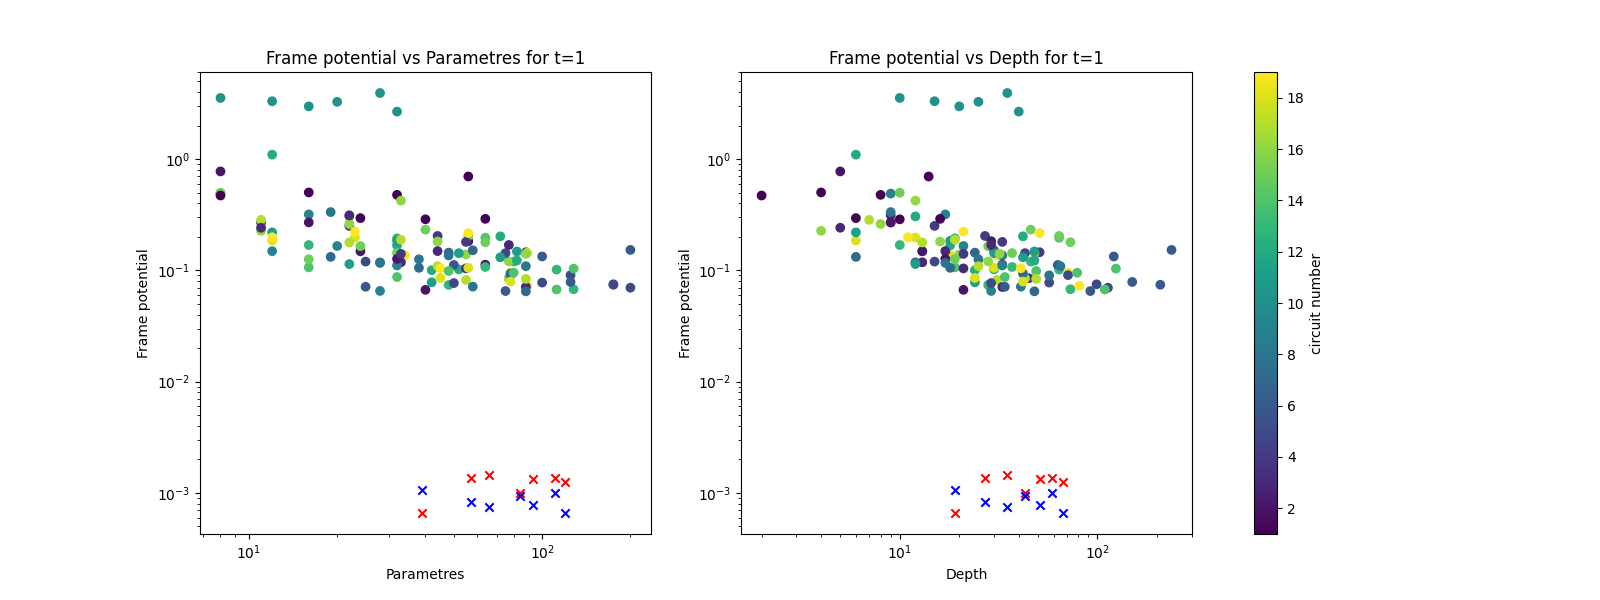

In [43]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t1[df_t1["name"] < 30]
df_highlight_1 = df_t1[df_t1["name"] == 30]
df_highlight_2 = df_t1[df_t1["name"] == 31]

# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
# give a red colo to the perfect_SU4 ansatz and a marker "x"
scatter1 = ax1.scatter(df_to_plot["n_parameters"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_highlight_1["n_parameters"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax1.scatter(df_highlight_2["n_parameters"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=1")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_highlight_1["circuit_depth"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax2.scatter(df_highlight_2["circuit_depth"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=1")
fig.colorbar(scatter2, label="circuit number", ax=[ax1, ax2])

cursor = mplcursors.cursor([scatter2, scatter1], hover=True)

# @cursor.connect("add")
# def on_add(sel):
#     i = sel.index
#     row = df_to_plot.iloc[i]
#     sel.annotation.set_text(
#     f"name={row['name']}\n"
#     f"n_qubits={row['n_qubits']}\n"
#     f"depth={row['circuit_depth']}\n"
#     f"n_params={row['n_parameters']}\n"
#     f"fp={row['frame_potential']:.3e}"
#     )

plt.show()

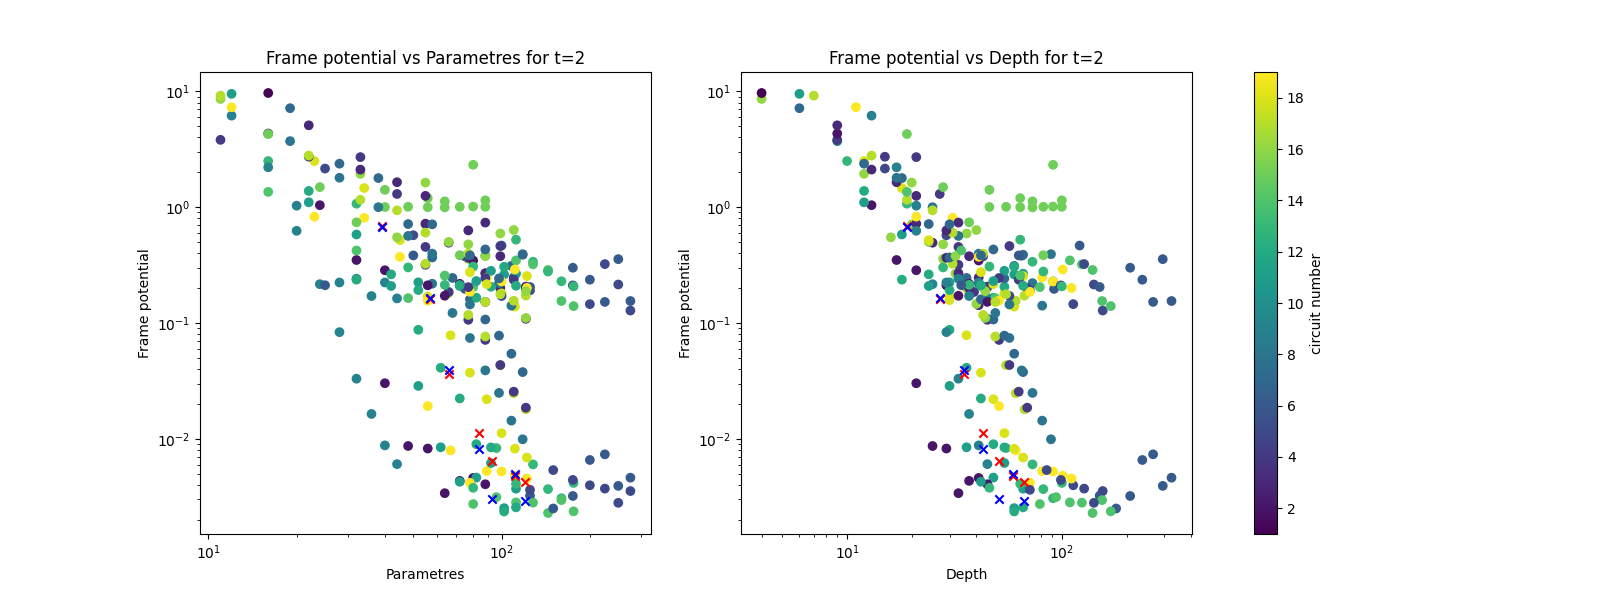

In [44]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t2[df_t2["name"] < 30]
df_highlight_1 = df_t2[df_t2["name"] == 30]
df_highlight_2 = df_t2[df_t2["name"] == 31]
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
scatter1 = ax1.scatter(df_to_plot["n_parameters"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_highlight_1["n_parameters"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax1.scatter(df_highlight_2["n_parameters"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=2")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_highlight_1["circuit_depth"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax2.scatter(df_highlight_2["circuit_depth"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=2")
fig.colorbar(scatter2, label="circuit number", ax=[ax1, ax2])


cursor = mplcursors.cursor([scatter2, scatter1], hover=True)

# @cursor.connect("add")
# def on_add(sel):
#     i = sel.index
#     row = df_to_plot.iloc[i]
#     sel.annotation.set_text(
#     f"name={row['name']}\n"
#     f"n_qubits={row['n_qubits']}\n"
#     f"depth={row['circuit_depth']}\n"
#     f"n_params={row['n_parameters']}\n"
#     f"fp={row['frame_potential']:.3e}\n"
#     f"fidelity_error={row['fidelity_error']:.3e}"
#     )

plt.show()

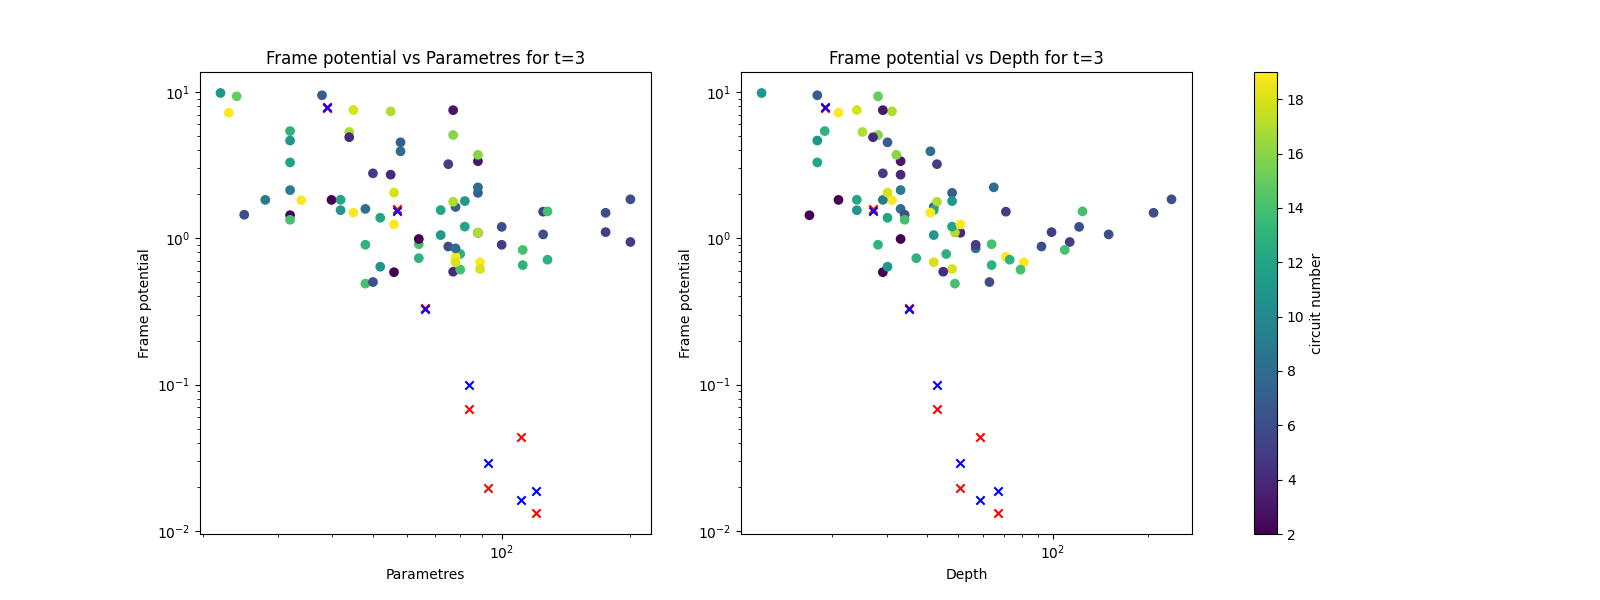

In [45]:
# plot the frame_potential depending on the parameters collored but the name of the ansatz
# use only the values where t = 1
df_to_plot = df_t3[df_t3["name"] < 30]
df_highlight_1 = df_t3[df_t3["name"] == 30]
df_highlight_2 = df_t3[df_t3["name"] == 31]
# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
scatter1 = ax1.scatter(df_to_plot["n_parameters"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax1.scatter(df_highlight_1["n_parameters"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax1.scatter(df_highlight_2["n_parameters"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=3")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["delta"],c=df_to_plot["name"], cmap="viridis")
ax2.scatter(df_highlight_1["circuit_depth"],df_highlight_1["delta"],c="red", marker="x", label="perfect_SU4")
ax2.scatter(df_highlight_2["circuit_depth"],df_highlight_2["delta"],c="blue", marker="x", label="perfect_SU4_composed")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=3")
fig.colorbar(scatter2, label="circuit number", ax=[ax1, ax2])

cursor = mplcursors.cursor([scatter2, scatter1], hover=True)

# @cursor.connect("add")
# def on_add(sel):
#     i = sel.index
#     row = df_to_plot.iloc[i]
#     sel.annotation.set_text(
#     f"name={row['name']}\n"
#     f"n_qubits={row['n_qubits']}\n"
#     f"depth={row['circuit_depth']}\n"
#     f"n_params={row['n_parameters']}\n"
#     f"fp={row['frame_potential']:.3e}\n"
#     f"fidelity_error={row['fidelity_error']:.3e}"
#     )

plt.show()

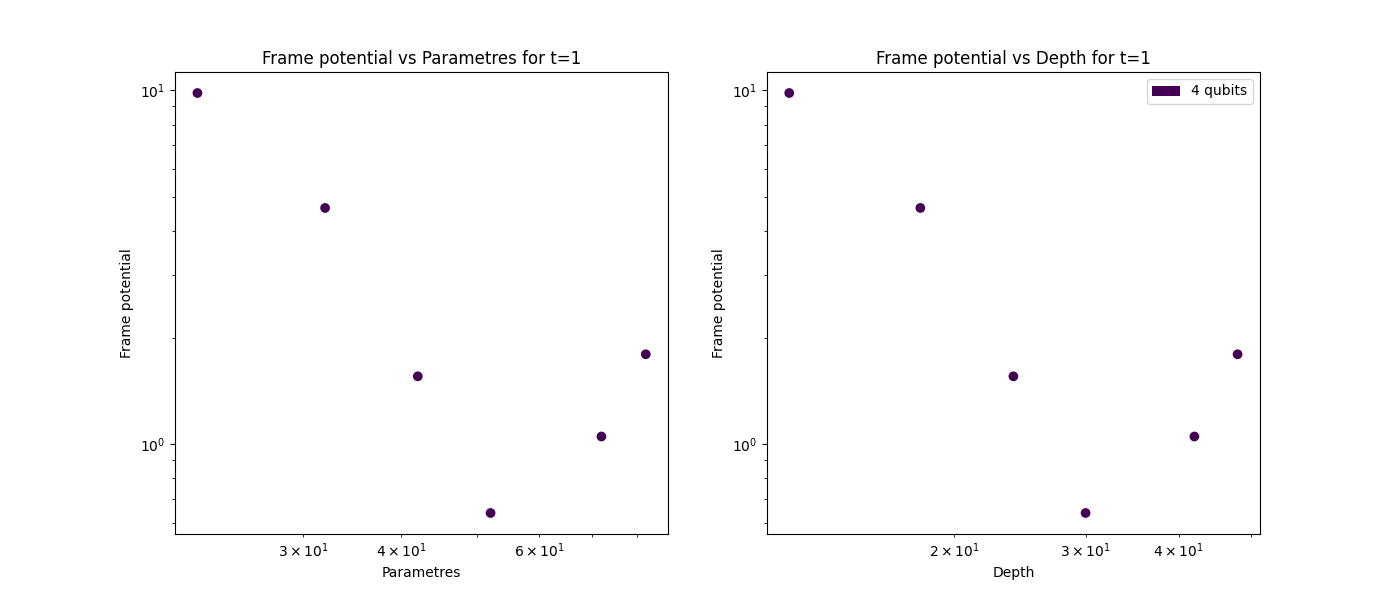

In [46]:



df_to_plot = df_t3[df_t3["name"] == 11]

# do 2 subplots one for the plot depending on the parameter the other for the plot depending on the depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.set_yscale('log')
ax1.set_xscale('log')

# do a log plot of the frame potential depending on the parameters collored but the name of the ansatz
ax1.scatter(df_to_plot["n_parameters"],df_to_plot["delta"],c=df_to_plot["n_qubits"], cmap="viridis")
ax1.set_xlabel("Parametres")
ax1.set_ylabel("Frame potential")
ax1.set_title("Frame potential vs Parametres for t=1")


ax2.set_yscale('log')
ax2.set_xscale('log')

scatter2 = ax2.scatter(df_to_plot["circuit_depth"],df_to_plot["delta"],c=df_to_plot["n_qubits"], cmap="viridis")
ax2.set_xlabel("Depth")
ax2.set_ylabel("Frame potential")
ax2.set_title("Frame potential vs Depth for t=1")

unique_vals = sorted(df_to_plot["n_qubits"].unique())
colors = cm.viridis(np.linspace(0, 1, len(unique_vals)))
legend_elements = [Patch(facecolor=colors[i], label=f"{int(val)} qubits") 
                   for i, val in enumerate(unique_vals)]
ax2.legend(handles=legend_elements, loc='best')
plt.show()